In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
# %matplotlib ipympl


import sys
sys.path.append('../src')
import satellites as sat


# Orbit Simulation: J2 correction

## Generate satellites objects

In [9]:
XHAT  = np.reshape( [1,0,0], [1,3])
YHAT  = np.reshape( [0,1,0], [1,3])
ZHAT  = np.reshape( [0,0,1], [1,3])

dist1 = sat.EARTH_RADIUS_M + 1000 # m low Earth orbit
vel1 = 7904.76692 # m/s approximate velocity to maintain orbit
mass1 = 100 # kg mass of object

npts = 100
rng = np.random.default_rng( seed = 123 )

rdilate = 1 # no variation in radius
phi = 0 # no variation in longitude
# rdilate = rng.uniform(0.9, 1.3, [npts,1])
# phi = const.pi * rng.uniform(0, 2, [npts,1])
theta = const.pi * rng.uniform(0.25, 0.5, [npts,1]) # randomize the starting position around the equator
velang = np.deg2rad( rng.uniform( 0, 3, [npts,1] )) # randomize the starting veolicty's angle

rvec = rdilate * (
    np.cos(phi)*np.sin(theta)*XHAT
    + np.sin(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )
thvec = (
    -np.sin(phi)*np.sin(theta)*XHAT
    + np.cos(phi)*np.sin(theta)*YHAT
    + np.cos(theta)*ZHAT
    )

sats = []
for r,th,va in zip(rvec, thvec, velang):
    rot = Rotation.from_rotvec( va * ZHAT )
    sats.append(
        sat.GravityObject( 
            xyz_m = dist1 * r,
            vxyz_mps = rot.as_matrix() @ (vel1*th),
            mass_kg=mass1
        )
    )

## Propagate objects as particles

In [10]:
DELTA_TIME_S = 2.0
N_TIME_STEPS = 20000

# init Earth system for simulation
esys = sat.EarthSystem( j2_correction=True, delta_time_s=DELTA_TIME_S )
for s in sats:
    esys.add_object( s )

esys.init_snapshots( )

for i in range(N_TIME_STEPS):
    esys.propagate_step()
    
r = np.stack(esys.positions)
v = np.stack(esys.velocities)
a = np.stack(esys.accels)

# init Earth system without J2 correction
esys_noj2 = sat.EarthSystem( j2_correction=False, delta_time_s=DELTA_TIME_S )
for s in sats:
    esys_noj2.add_object( s )

esys_noj2.init_snapshots( )

for i in range(N_TIME_STEPS):
    esys_noj2.propagate_step()
    
r_noj2 = np.stack(esys_noj2.positions)
v_noj2 = np.stack(esys_noj2.velocities)
a_noj2 = np.stack(esys_noj2.accels)

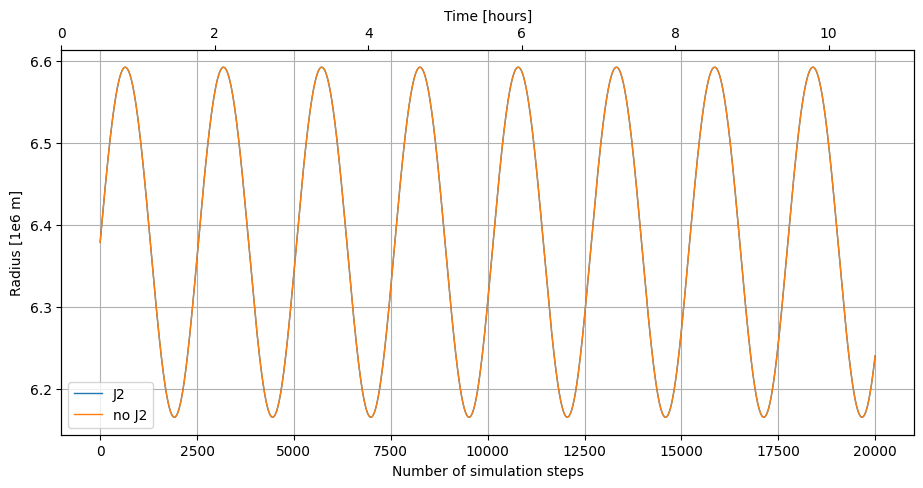

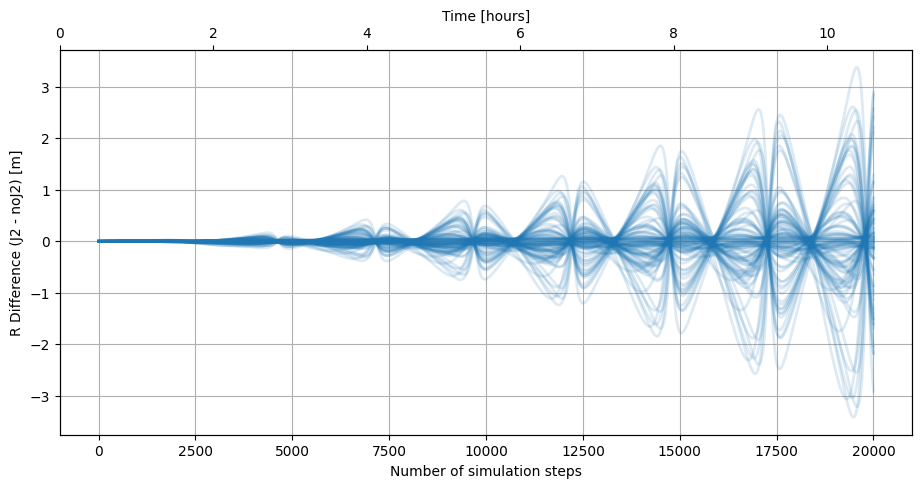

In [11]:
fig, ax = plt.subplots( 1,1, figsize=[11,5])
distances = LA.norm( r, axis=2 )
distances_noj2 = LA.norm( r_noj2, axis=2 )

scaletime = 1/3600
timevec = np.arange(r.shape[0])
scaley = 1/const.mega
ax.plot( timevec, scaley*distances[:,0], lw=1, color='tab:blue', label='J2')
ax.plot( timevec, scaley*distances_noj2[:,0], lw=1, color='tab:orange', label='no J2')
# Create twin axis sharing y-axis
ax2 = ax.twiny()
ax2.set_xlabel('Time [hours]')

ax2.set_xlim(0, scaletime*DELTA_TIME_S*N_TIME_STEPS)  # Different range

axkwargs = {
    'xlabel':'Number of simulation steps',
    'ylabel': 'Radius [1e6 m]',
}
ax.set(**axkwargs)
ax.grid(True)
ax.legend()


fig, ax = plt.subplots( 1,1, figsize=[11,5])

ax.plot( timevec, distances - distances_noj2, lw=2, color='tab:blue', alpha=0.15 )
# Create twin axis sharing y-axis
ax2 = ax.twiny()
ax2.set_xlabel('Time [hours]')

ax2.set_xlim(0, scaletime*DELTA_TIME_S*N_TIME_STEPS)  # Different range

axkwargs = {
    'xlabel':'Number of simulation steps',
    'ylabel': 'R Difference (J2 - noJ2) [m]',
}
ax.set(**axkwargs)
ax.grid(True)

plt.show()

### Discussion

The simulation of orbital trajectories is based on a step-by-step integration of the particle-like object's acceleration. The Earth's gravitational potential gives the object's acceleration at a given point in space. From the acceleration, the velocity and then the position are calculated by a "Velocty Verlet" intergration step. The Verlet integrator provides 
- numerical stability for the particle trajectories 
- time reversibility
- preservation of the system's phase-space volume 

The **velocity Verlet** recursion equations for Newton's equations are:

1. Compute the new position, $r_{k+1}$ from the previous state $x_k = (r,v,a)_k$
$$r_{k+1} = r_k + \Delta t v_k + \frac{a_k^2}{2}\Delta t$$

2. Compute the new acceleration based from the potential based on the new position
$$a_{k+1} = A(r_{k+1})$$

3. Compute the new veloctiy from the mean of the new and old accelerations
$$v_{k+1} = v_k + \frac{(a_k + a_{k+1})}{2}\Delta t$$

In general, the time-step, $\Delta t$ can also depend on the iteration number i.e. $\Delta t_k$. Also note that the acceleration update assumes that the acceleration at a time-step $k$ only depends on the position of the particle at that time-step. 


Note that since the velocity Verlet requires knowledge of the kinematic state in the previous two steps, an initialization procedure is needed. Fortunately, it is sufficient to use a basic forward Euler integration scheme to generate the first two states. 

**Forward Euler**:
$$a_{k+1} = a_{k} = a_{0}$$
$$v_{k+1} = v_{k} + a_{0}\Delta t$$
$$r_{k+1} = r_{l} + v_{k}\Delta t + \frac{a_{0}}{2}\Delta t^{2} $$

### J2 correction
The J2 correction is a second order term in the spherical harmonics expansion of Earth's gravitational potential. It accounts for the slight flattening at poles due to Earth's rotation. 

The trajectories without the J2 correction deviate from those with the correction. By 5000th step the difference in radial distance begins to creep up. By the 20000th simulation iteration, the radial distance difference between the two simulations is oscillating at 3 meters depending on the initial conditions of the particles/satellites. 


